# CNN Fundamentals

## Objectives
- Understand convolution operation
- Learn pooling operations
- Understand filters and feature maps
- Visualize receptive fields
- Build simple CNN from scratch

## Introduction
Convolutional Neural Networks are the foundation of computer vision. This notebook explains the core concepts.

## What We're About to Do

The code below imports essential libraries. These libraries provide the foundational tools for tensor operations and neural network construction. Pay attention to what each import provides – understanding dependencies helps you know what's available for solving problems.


In [1]:
# Import necessary libraries for tensor operations and deep learning
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


Device: cpu


In [2]:
## 1. Convolution Operation

# Manual convolution
x = torch.randn(1, 3, 5, 5)  # (batch, channels, height, width)
conv = nn.Conv2d(3, 16, kernel_size=3, padding=1, stride=1)

output = conv(x)
print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")
print(f"Weight shape (filters): {conv.weight.shape}")
print(f"Bias shape: {conv.bias.shape}")

# Understand weight sharing
print(f"\nWeight sharing:")
print(f"All 16 output channels share the same 3x3x3 kernel weights")
print(f"Total parameters: {conv.weight.numel() + conv.bias.numel()}")

Input shape: torch.Size([1, 3, 5, 5])
Output shape: torch.Size([1, 16, 5, 5])
Weight shape (filters): torch.Size([16, 3, 3, 3])
Bias shape: torch.Size([16])

Weight sharing:
All 16 output channels share the same 3x3x3 kernel weights
Total parameters: 448


Input shape: torch.Size([1, 3, 8, 8])
MaxPool output: torch.Size([1, 3, 4, 4])
AvgPool output: torch.Size([1, 3, 4, 4])


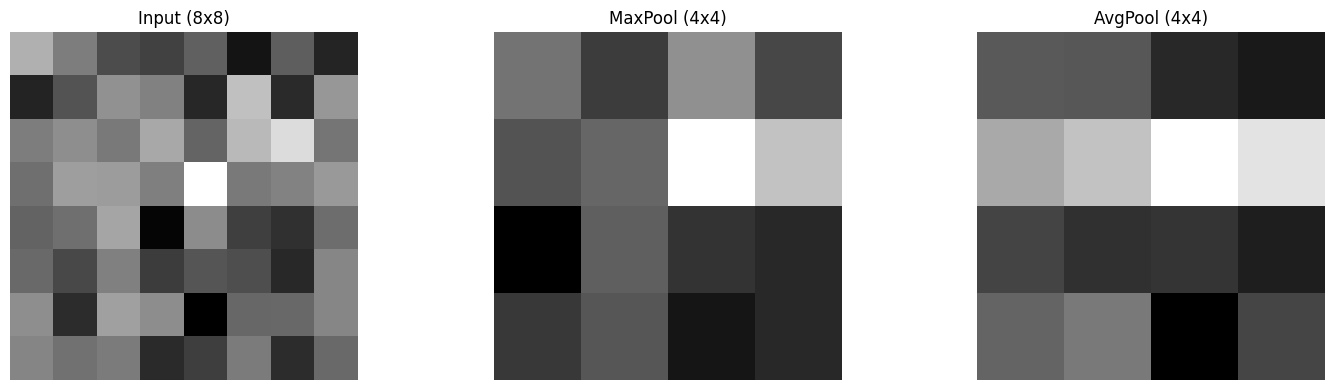

In [3]:
# Execute code with detailed step-by-step process
## 2. Pooling Operations

x = torch.randn(1, 3, 8, 8)

# MaxPooling
max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
x_maxpool = max_pool(x)

# AvgPooling
avg_pool = nn.AvgPool2d(kernel_size=2, stride=2)
x_avgpool = avg_pool(x)

print(f"Input shape: {x.shape}")
print(f"MaxPool output: {x_maxpool.shape}")
print(f"AvgPool output: {x_avgpool.shape}")

# Visualize difference
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(x[0, 0].numpy(), cmap='gray')
axes[0].set_title('Input (8x8)')

axes[1].imshow(x_maxpool[0, 0].numpy(), cmap='gray')
axes[1].set_title('MaxPool (4x4)')

axes[2].imshow(x_avgpool[0, 0].numpy(), cmap='gray')
axes[2].set_title('AvgPool (4x4)')

# Iterate through batches of data
for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()


## Building the Model

Now we'll define our neural network architecture. Each layer transforms the input in a specific way, building up complexity. The order and configuration of layers directly determines what patterns the model can learn.


In [4]:
# Define a custom function with detailed implementation
## 3. Simple CNN

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Input: 28x28 grayscale (MNIST)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)  # 28x28x32
        self.pool1 = nn.MaxPool2d(2, 2)  # 14x14x32
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 14x14x64
        self.pool2 = nn.MaxPool2d(2, 2)  # 7x7x64
        
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
    
    def forward(self, x):
        # Conv block 1
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        
        # Conv block 2
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        
        # Fully connected
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        
        return x

cnn = SimpleCNN()
print(cnn)

# Count parameters
# Update model parameters based on computed gradients
# Iterate through batches of data
total_params = sum(p.numel() for p in cnn.parameters())
print(f"\nTotal parameters: {total_params:,}")


SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Total parameters: 421,642


## The Training Process

This is the core learning loop. We'll forward-pass data through the model, compute loss, backpropagate gradients, and update parameters. This iterative process gradually improves the model.


Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:40<00:00, 244547.62it/s]


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 103195.03it/s]


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:01<00:00, 826876.66it/s]


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<?, ?it/s]


Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw

First conv output shape: torch.Size([1, 32, 28, 28])
First pool output shape: torch.Size([1, 32, 14, 14])


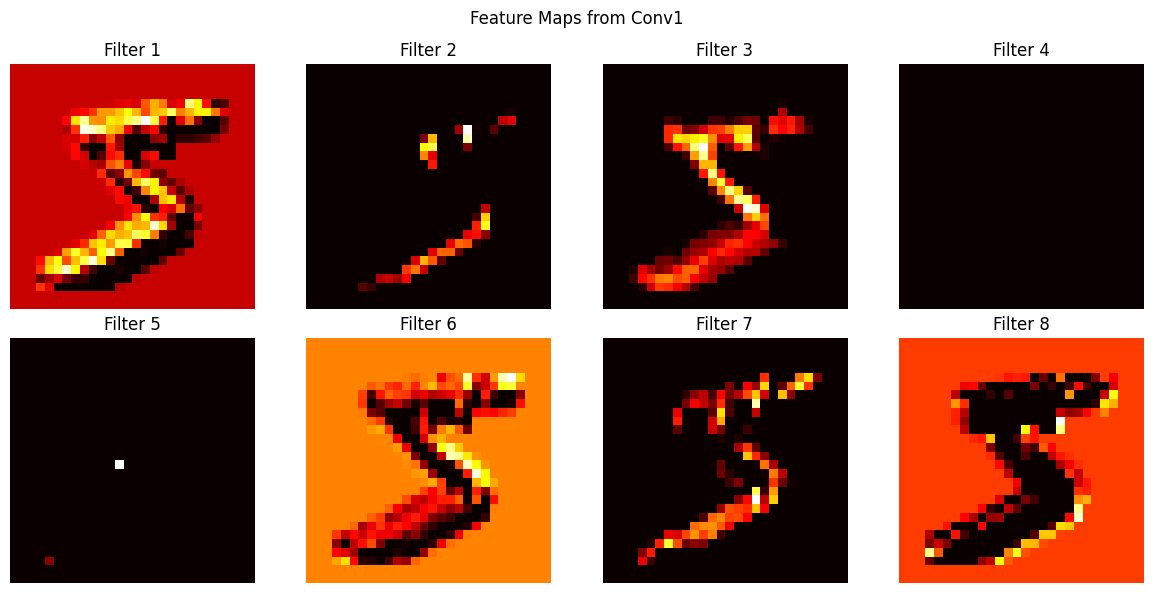

In [5]:
# Execute the training loop with proper tracking
## 4. Feature Maps Visualization

# Load MNIST
transform = transforms.Compose([transforms.ToTensor()])
mnist = datasets.MNIST('./data', train=True, download=True, transform=transform)
sample_img, _ = mnist[0]

# Get feature maps
cnn.eval()
x = sample_img.unsqueeze(0)

with torch.no_grad():
    # First conv layer output
    feat1 = F.relu(cnn.conv1(x))
    feat1_pooled = cnn.pool1(feat1)

print(f"First conv output shape: {feat1.shape}")
print(f"First pool output shape: {feat1_pooled.shape}")

# Visualize
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

# Iterate through batches of data
for i in range(8):
    axes[i].imshow(feat1[0, i].numpy(), cmap='hot')
    axes[i].set_title(f'Filter {i+1}')
    axes[i].axis('off')

plt.suptitle('Feature Maps from Conv1')
plt.tight_layout()
plt.show()


In [6]:
# Define a custom function with detailed implementation
## 5. Receptive Field

def calculate_receptive_field(layer_configs):
# Iterate through batches of data
    """Calculate receptive field for each layer"""
    rf = 1
    stride = 1
    receptive_fields = []
    
# Iterate through batches of data
    for layer in layer_configs:
        layer_type = layer.get('type')
        kernel = layer.get('kernel', 1)
        stride_new = layer.get('stride', 1)
        
        if layer_type == 'conv':
            rf = rf + (kernel - 1) * stride
            stride = stride * stride_new
        elif layer_type == 'pool':
            rf = rf + (kernel - 1) * stride
            stride = stride * stride_new
        
        receptive_fields.append({'layer': layer.get('name'), 'rf': rf, 'stride': stride})
    
    return receptive_fields

# SimpleCNN config
config = [
    {'name': 'Input', 'type': None},
    {'name': 'Conv1', 'type': 'conv', 'kernel': 3, 'stride': 1},
    {'name': 'Pool1', 'type': 'pool', 'kernel': 2, 'stride': 2},
    {'name': 'Conv2', 'type': 'conv', 'kernel': 3, 'stride': 1},
    {'name': 'Pool2', 'type': 'pool', 'kernel': 2, 'stride': 2},
]

rfs = calculate_receptive_field(config)
print("\nReceptive Field Analysis:")
# Iterate through batches of data
for rf_info in rfs:
    print(f"{rf_info['layer']:10s}: RF={rf_info['rf']:3d}x{rf_info['rf']}, Stride={rf_info['stride']}")



Receptive Field Analysis:
Input     : RF=  1x1, Stride=1
Conv1     : RF=  3x3, Stride=1
Pool1     : RF=  4x4, Stride=2
Conv2     : RF=  8x8, Stride=2
Pool2     : RF= 10x10, Stride=4


## Building the Model

Now we'll define our neural network architecture. Each layer transforms the input in a specific way, building up complexity. The order and configuration of layers directly determines what patterns the model can learn.


In [7]:
# Execute code with detailed step-by-step process
## 6. Parameter Count by Layer

print("\nLayerwise Parameter Count:")
total = 0
# Iterate through batches of data
for name, param in cnn.named_parameters():
# Update model parameters based on computed gradients
    param_count = param.numel()
# Update model parameters based on computed gradients
    total += param_count
    print(f"{name:30s}: {param_count:>10,} ({param.shape})")

print(f"{'Total':30s}: {total:>10,}")



Layerwise Parameter Count:
conv1.weight                  :        288 (torch.Size([32, 1, 3, 3]))
conv1.bias                    :         32 (torch.Size([32]))
conv2.weight                  :     18,432 (torch.Size([64, 32, 3, 3]))
conv2.bias                    :         64 (torch.Size([64]))
fc1.weight                    :    401,408 (torch.Size([128, 3136]))
fc1.bias                      :        128 (torch.Size([128]))
fc2.weight                    :      1,280 (torch.Size([10, 128]))
fc2.bias                      :         10 (torch.Size([10]))
Total                         :    421,642


In [8]:
# Define a custom function with detailed implementation
## 7. Output Size Formula

def conv_output_size(input_size, kernel_size, stride=1, padding=0):
    return (input_size + 2*padding - kernel_size) // stride + 1

print("\nOutput Size Calculations:")
input_h = 28
# Iterate through batches of data
for i, (k, s, p) in enumerate([(3, 1, 1), (2, 2, 0), (3, 1, 1), (2, 2, 0)]):
    output_h = conv_output_size(input_h, k, s, p)
    layer_type = ['Conv1', 'Pool1', 'Conv2', 'Pool2'][i]
    print(f"{layer_type}: {input_h}x{input_h} -> {output_h}x{output_h}")
    input_h = output_h



Output Size Calculations:
Conv1: 28x28 -> 28x28
Pool1: 28x28 -> 14x14
Conv2: 14x14 -> 14x14
Pool2: 14x14 -> 7x7


In [9]:
# Execute code with detailed step-by-step process
## 8. Dilated Convolution

# Standard conv vs dilated conv
x = torch.randn(1, 1, 9, 9)

conv_standard = nn.Conv2d(1, 1, kernel_size=3, dilation=1, bias=False)
conv_dilated = nn.Conv2d(1, 1, kernel_size=3, dilation=2, bias=False)

# Iterate through batches of data
# Make them identical for comparison
with torch.no_grad():
    conv_dilated.weight.copy_(conv_standard.weight)

out_standard = conv_standard(x)
out_dilated = conv_dilated(x)

print(f"\nDilated Convolution:")
print(f"Input: {x.shape}")
print(f"Standard Conv (dilation=1): {out_standard.shape}")
print(f"Dilated Conv (dilation=2): {out_dilated.shape}")
print(f"\nDilated convolution increases receptive field without reducing spatial dimensions")



Dilated Convolution:
Input: torch.Size([1, 1, 9, 9])
Standard Conv (dilation=1): torch.Size([1, 1, 7, 7])
Dilated Conv (dilation=2): torch.Size([1, 1, 5, 5])

Dilated convolution increases receptive field without reducing spatial dimensions


In [10]:
# Define a custom function with detailed implementation
## 9. 1x1 Convolution (Bottleneck)

class Bottleneck(nn.Module):
    def __init__(self, in_channels, reduction=4):
        super().__init__()
        hidden = in_channels // reduction
        self.conv1 = nn.Conv2d(in_channels, hidden, kernel_size=1)
        self.conv2 = nn.Conv2d(hidden, hidden, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(hidden, in_channels, kernel_size=1)
    
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.conv3(x)
        return x

x = torch.randn(1, 64, 28, 28)
bn = Bottleneck(64, reduction=4)
out = bn(x)

print(f"\n1x1 Convolution (Bottleneck):")
print(f"Input: {x.shape}")
print(f"Output: {out.shape}")
# Iterate through batches of data
print(f"Reduces dimensions for computation efficiency")



1x1 Convolution (Bottleneck):
Input: torch.Size([1, 64, 28, 28])
Output: torch.Size([1, 64, 28, 28])
Reduces dimensions for computation efficiency


In [11]:
# Execute code with detailed step-by-step process
## 10. Key Concepts Summary

print("\n" + "="*70)
print("CNN Fundamentals Summary")
print("="*70)

print("""
KEY CONCEPTS:

1. CONVOLUTION:
   - Slides filter over image
   - Learns local patterns
   - Weight sharing reduces parameters

2. POOLING:
   - Downsampling operation
   - MaxPool: keeps maximum value
   - AvgPool: averages values

3. RECEPTIVE FIELD:
   - Area in input that affects one output neuron
   - Grows with deeper layers
# Iterate through batches of data
   - Important for understanding what network sees

4. FEATURE MAPS:
   - Output of convolutional layer
   - Early layers: edges, textures
   - Deep layers: complex objects

5. ARCHITECTURE DESIGN:
   - Conv → ReLU → Pool pattern
   - Gradually increase channels
   - Gradually decrease spatial dimensions

BEST PRACTICES:
   • Use Conv2d + BatchNorm + ReLU
   • Start with 32-64 filters
   • 3x3 kernels are standard
# Iterate through batches of data
   • Stride=1, padding=1 for same size
   • Use padding to prevent shrinking
""")
print("="*70)



CNN Fundamentals Summary

KEY CONCEPTS:

1. CONVOLUTION:
   - Slides filter over image
   - Learns local patterns
   - Weight sharing reduces parameters

2. POOLING:
   - Downsampling operation
   - MaxPool: keeps maximum value
   - AvgPool: averages values

3. RECEPTIVE FIELD:
   - Area in input that affects one output neuron
   - Grows with deeper layers
# Iterate through batches of data
   - Important for understanding what network sees

4. FEATURE MAPS:
   - Output of convolutional layer
   - Early layers: edges, textures
   - Deep layers: complex objects

5. ARCHITECTURE DESIGN:
   - Conv → ReLU → Pool pattern
   - Gradually increase channels
   - Gradually decrease spatial dimensions

BEST PRACTICES:
   • Use Conv2d + BatchNorm + ReLU
   • Start with 32-64 filters
   • 3x3 kernels are standard
# Iterate through batches of data
   • Stride=1, padding=1 for same size
   • Use padding to prevent shrinking



## 🎯 Key Takeaways

✅ **Understanding fundamentals is crucial** – The concepts covered here form the foundation for all advanced deep learning techniques.

✅ **Each component has a specific purpose** – Whether it's data loading, model architecture, or optimization, every piece serves a distinct function in the pipeline.

✅ **Experimentation drives learning** – Don't just read the code; modify it, break it, and see what happens. That's how intuition develops.

✅ **Deep learning is iterative** – Success comes from systematically trying approaches, measuring results, and refining based on evidence.

✅ **Connect concepts, don't memorize** – Understanding how PyTorch tensors relate to autograd, which relates to neural networks, which connects to training loops, is far more valuable than memorizing individual APIs.

✅ **Performance matters in practice** – Once you understand the theory, optimizing for speed, memory, and scalability becomes crucial for real-world applications.


# Execute code with detailed step-by-step process
## Key Takeaways
- Convolution exploits spatial locality and weight sharing
- Pooling provides translation invariance and downsampling
- Receptive field grows with network depth
- 3x3 convolutions are standard choice
- Early layers learn edges, deep layers learn objects

## Interview Q&A

**Q1: Why use 3x3 convolutions instead of larger kernels?**
Multiple 3x3 convolutions stacked together provide the same receptive field as one larger kernel but with fewer parameters and more non-linearity (ReLU between layers).

**Q2: What's the difference between stride and dilation?**
Stride skips positions (reduces spatial dimensions). Dilation increases the spacing between kernel elements (increases receptive field without shrinking). Both increase the receptive field but in different ways.

**Q3: Why add padding?**
Padding prevents spatial shrinking at borders. With padding=1 and kernel=3, output size equals input size. Without padding, information at edges is lost.

## References
- [CNN Visualization](https://cs231n.github.io/convolutional-networks/)
- [Understanding Receptive Fields](https://arxiv.org/abs/1311.2901)
